## Task: Numerically simulate the motion of a simple pendulum beyond the small-angle approximation. Can you find a value for the initial velocity which causes the pendulum to stand up vertically? Compare your results to the exact expressions relevant to the small-angle approximation

In [7]:
## Necessary Imports
import numpy as np
import matplotlib.pyplot as plt 

def Euler(t1, x0, k, h):
    """ODE Solver for ODEs of the form dx/dt = kx using Euler Method. 
    Assumes that the initial condition is given at t = 0 
       
    Args: 
        t1: time to solve the equation up to
        x0: starting value of x, at t = 0
        k:  value of k in the ODE equation
        h:  step size of the method 
        
    Returns:
        t: An array in increments of h for the dimension of time up to t1
        x: An array in increments of h for the dimension of space up to x(t1)
    """
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # x starts as an empty array, but we will fill in the values we calculate in the loop, below
    x = np.zeros(n) 
    
    #Set the initial value of x (i.e. x[0])
    x[0] = x0
    
    #Loop over the time values and calculate the derivative
    for i in range(1,n): 
        x[i] = x[i-1] + h*k*x[i-1] 
    
    return(t,x) 

In [8]:
# for now set k = -g/l where l = 1 so k=-9.8

# Calling function with specified t1, x0, k, and h
h = 0.5

# Running Euler method to obtain numerical solution
t_euler, x_euler = Euler(10, np.pi/4, -9.8, h)

# Analytical solution
t_analytical = t_euler  # Using the same time points for analytical solution
x_analytical = 10 * np.exp(k * t_analytical)

# Plotting the results
plt.figure(figsize=(13, 9))
plt.title('Exercise 1a')
plt.plot(t_euler, x_euler, label='Euler Method')
plt.plot(t_analytical, x_analytical, label='Analytical Solution')
plt.xlabel('Time (s)')
plt.ylabel('Angle')
plt.legend()
plt.show()

NameError: name 'k' is not defined

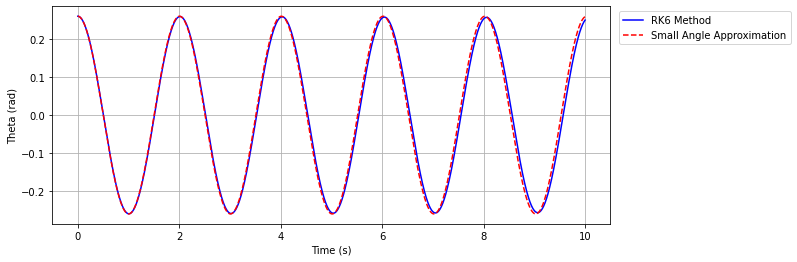

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the pendulum
g = 9.81  # Acceleration due to gravity (m/s^2)
l = 1.0   # Length of the pendulum (m)
theta_0 = 0.26  # Initial angle in radians
v0 = 0    # Initial angular velocity (rad/s)
t1 = 10 # Total time for the simulation
h = 0.001  # Step size for RK4

# Define the RK6 function for a single arm pendulum beyond small angles
def RK6(t1, theta_0, v0, g, l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v0
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    for i in range(1, n):
        
        k1_v = h * F(theta[i-1])
        k1_theta = h * G(v[i-1])

        k2_v = h * F(theta[i-1] + k1_theta / 4)
        k2_theta = h * G(v[i-1] + k1_v / 4)

        k3_v = h * F(theta[i-1] + k2_theta / 4)
        k3_theta = h * G(v[i-1] + k2_v / 4)

        k4_v = h * F(theta[i-1] + k3_theta / 2)
        k4_theta = h * G(v[i-1] + k3_v / 2)

        
        k5_v = h * F(theta[i-1] - k4_theta + 2 * k3_theta)
        k5_theta = h * G(v[i-1] - k4_v + 2 * k3_v)

        k6_v = h * F(theta[i-1] + (7 * k1_theta + 6 * k2_theta + 8 * k3_theta + 3 * k4_theta) / 14)
        k6_theta = h * G(v[i-1] + (7 * k1_v + 6 * k2_v + 8 * k3_v + 3 * k4_v) / 14)



        # RK6 weights
        theta[i] = theta[i-1] + (7 * k1_theta + 32 * k3_theta + 12 * k4_theta + 32 * k5_theta + 7 * k6_theta) / 90
        v[i] = v[i-1] + (7 * k1_v + 32 * k3_v + 12 * k4_v + 32 * k5_v + 7 * k6_v) / 90
        
        if theta[i] >= 2*np.pi:
            theta[i] = theta[i]-2*np.pi

    return t,theta,v
# Run the RK4 method
t_rk6, theta_rk6, v_rk6 = RK6(t1, theta_0, v0, g, l, h)

# Solution for small angles
t_small_angle = np.arange(0, t1+h, h)
theta_small_angle = theta_0 * np.cos(np.sqrt(g/l) * t_small_angle)

# Plotting both the small angle approximation and RK4 method
plt.figure(figsize = (10,4))
plt.plot(t_rk6, theta_rk6, label='RK6 Method', linestyle='-', color='blue')
plt.plot(t_small_angle, theta_small_angle, label='Small Angle Approximation', linestyle='--', color='red')
#plt.title('Small Angle Approximation vs. RK4 Method')
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.legend(bbox_to_anchor=(1.007, 1), fontsize=10)
plt.grid(True)
plt.savefig('small_rk6_sangle.png', dpi=300)
plt.show()

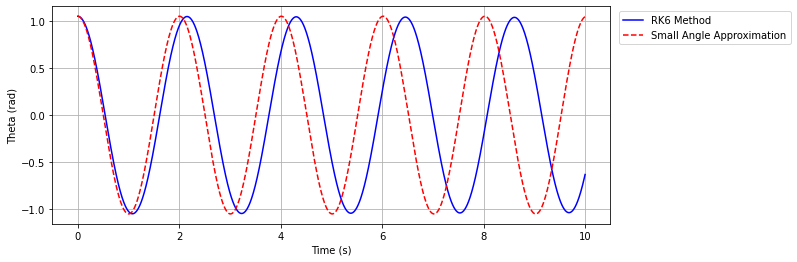

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the pendulum
g = 9.81  # Acceleration due to gravity (m/s^2)
l = 1.0   # Length of the pendulum (m)
theta_0 = 1.05  # Initial angle in radians
v0 = 0    # Initial angular velocity (rad/s)
t1 = 10 # Total time for the simulation
h = 0.001  # Step size for RK4

# Define the RK6 function for a single arm pendulum beyond small angles
def RK6(t1, theta_0, v0, g, l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v0
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    for i in range(1, n):
        
        k1_v = h * F(theta[i-1])
        k1_theta = h * G(v[i-1])

        k2_v = h * F(theta[i-1] + k1_theta / 4)
        k2_theta = h * G(v[i-1] + k1_v / 4)

        k3_v = h * F(theta[i-1] + k2_theta / 4)
        k3_theta = h * G(v[i-1] + k2_v / 4)

        k4_v = h * F(theta[i-1] + k3_theta / 2)
        k4_theta = h * G(v[i-1] + k3_v / 2)

        
        k5_v = h * F(theta[i-1] - k4_theta + 2 * k3_theta)
        k5_theta = h * G(v[i-1] - k4_v + 2 * k3_v)

        k6_v = h * F(theta[i-1] + (7 * k1_theta + 6 * k2_theta + 8 * k3_theta + 3 * k4_theta) / 14)
        k6_theta = h * G(v[i-1] + (7 * k1_v + 6 * k2_v + 8 * k3_v + 3 * k4_v) / 14)



        # RK6 weights
        theta[i] = theta[i-1] + (7 * k1_theta + 32 * k3_theta + 12 * k4_theta + 32 * k5_theta + 7 * k6_theta) / 90
        v[i] = v[i-1] + (7 * k1_v + 32 * k3_v + 12 * k4_v + 32 * k5_v + 7 * k6_v) / 90
        
        if theta[i] >= 2*np.pi:
            theta[i] = theta[i]-2*np.pi

    return t,theta,v

# Run the RK6 method
t_rk6, theta_rk6, v_rk6 = RK6(t1, theta_0, v0, g, l, h)

# Solution for small angles
t_small_angle = np.arange(0, t1+h, h)
theta_small_angle = theta_0 * np.cos(np.sqrt(g/l) * t_small_angle)

# Plotting both the small angle approximation and RK4 method
plt.figure(figsize=(10, 4))
plt.plot(t_rk6, theta_rk6, label='RK6 Method', linestyle='-', color='blue')
plt.plot(t_small_angle, theta_small_angle, label='Small Angle Approximation', linestyle='--', color='red')
#plt.title('Small Angle Approximation vs. RK6 Method')
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.legend(bbox_to_anchor=(1.007, 1), fontsize=10)
plt.grid(True)
#plt.figsize(figsize=())
plt.savefig('small_rk6_bangle.png', dpi=300)
plt.show()

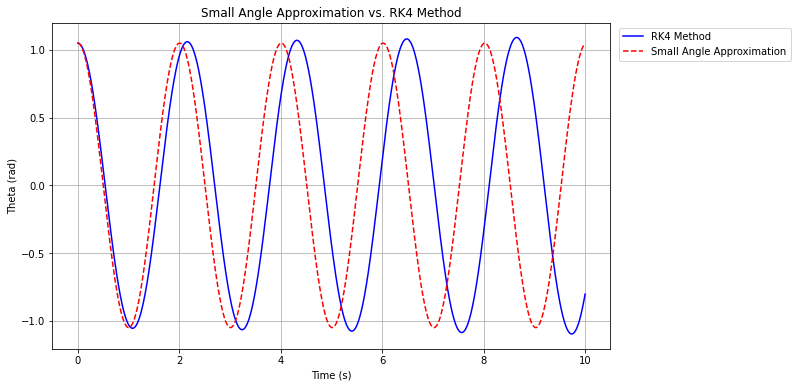

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the pendulum
g = 9.81  # Acceleration due to gravity (m/s^2)
l = 1.0   # Length of the pendulum (m)
theta_0 = 1.05  # Initial angle in radians
v0 = 0    # Initial angular velocity (rad/s)
t1 = 10 # Total time for the simulation
h = 0.001  # Step size for RK4

# Define the RK4 function for a single arm pendulum beyond small angles
def RK4(t1, theta_0, v0, g, l, h):
    t = np.arange(0, t1+h, h)
    n = len(t)
    theta = np.zeros(n)
    v = np.zeros(n)
    
    theta[0] = theta_0
    v[0] = v0
    
    def F(theta):
        return -g / l * np.sin(theta)
    
    def G(v):
        return v
    
    for i in range(1, n):
        f1 = h * F(theta[i-1])
        f2 = h * F(theta[i-1] + f1/2)
        f3 = h * F(theta[i-1] + f2/2)
        f4 = h * F(theta[i-1] + f3)
        
        g1 = h * G(v[i-1])
        g2 = h * G(v[i-1] + g1/2)
        g3 = h * G(v[i-1] + g2/2)
        g4 = h * G(v[i-1] + g3)
        
        theta[i] = theta[i-1] + (g1 + 2*g2 + 2*g3 + g4) / 6
        v[i] = v[i-1] + (f1 + 2*f2 + 2*f3 + f4) / 6
    
    return t, theta, v

# Run the RK4 method
t_rk4, theta_rk4, v_rk4 = RK4(t1, theta_0, v0, g, l, h)

# Solution for small angles
t_small_angle = np.arange(0, t1+h, h)
theta_small_angle = theta_0 * np.cos(np.sqrt(g/l) * t_small_angle)

# Plotting both the small angle approximation and RK4 method
plt.figure(figsize=(10, 6))
plt.plot(t_rk4, theta_rk4, label='RK4 Method', linestyle='-', color='blue')
plt.plot(t_small_angle, theta_small_angle, label='Small Angle Approximation', linestyle='--', color='red')
plt.title('Small Angle Approximation vs. RK4 Method')
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.legend(bbox_to_anchor=(1.007, 1), fontsize=10)
plt.grid(True)
plt.savefig('small_rk4_bangle.png', dpi=300)
plt.show()

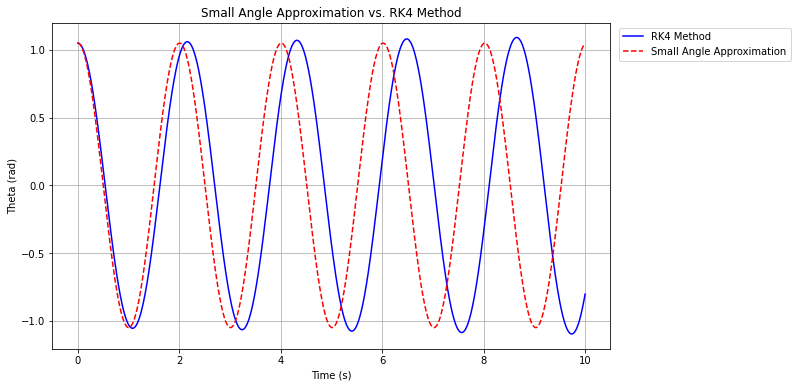

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the pendulum
g = 9.81  # Acceleration due to gravity (m/s^2)
l = 1.0   # Length of the pendulum (m)
theta_0 = 1.05  # Initial angle in radians
v0 = 0    # Initial angular velocity (rad/s)
t1 = 10 # Total time for the simulation
h = 0.001  # Step size for RK4

# Define the RK4 function for a single arm pendulum beyond small angles
def RK4(t1, theta_0, v0, g, l, h):
    t = np.arange(0, t1+h, h)
    n = len(t)
    theta = np.zeros(n)
    v = np.zeros(n)
    
    theta[0] = theta_0
    v[0] = v0
    
    def F(theta):
        return -g / l * np.sin(theta)
    
    def G(v):
        return v
    
    for i in range(1, n):
        f1 = h * F(theta[i-1])
        f2 = h * F(theta[i-1] + f1/2)
        f3 = h * F(theta[i-1] + f2/2)
        f4 = h * F(theta[i-1] + f3)
        
        g1 = h * G(v[i-1])
        g2 = h * G(v[i-1] + g1/2)
        g3 = h * G(v[i-1] + g2/2)
        g4 = h * G(v[i-1] + g3)
        
        theta[i] = theta[i-1] + (g1 + 2*g2 + 2*g3 + g4) / 6
        v[i] = v[i-1] + (f1 + 2*f2 + 2*f3 + f4) / 6
    
    return t, theta, v

# Run the RK4 method
t_rk4, theta_rk4, v_rk4 = RK4(t1, theta_0, v0, g, l, h)

# Solution for small angles
t_small_angle = np.arange(0, t1+h, h)
theta_small_angle = theta_0 * np.cos(np.sqrt(g/l) * t_small_angle)

# Plotting both the small angle approximation and RK4 method
plt.figure(figsize=(10, 6))
plt.plot(t_rk4, theta_rk4, label='RK4 Method', linestyle='-', color='blue')
plt.plot(t_small_angle, theta_small_angle, label='Small Angle Approximation', linestyle='--', color='red')
plt.title('Small Angle Approximation vs. RK4 Method')
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.legend(bbox_to_anchor=(1.007, 1), fontsize=10)
plt.grid(True)
plt.savefig('small_rk4_bangle.png', dpi=300)
plt.show()

In [13]:
#Define the function
def RK4(t1, theta_0, v_0, l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    E = np.zeros(n)
    
    g = 9.81
    m = 1
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v_0
    E[0] = 0.5 * m * v_0**2 + m * g * l * (1-np.cos(theta_0))
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    
    #Loop over the time values and calculate the derivatives
    for i in range(1,n): 
        
        # Calculate the Runge - Kutta intermediate values
        f1 = h * F(theta[i-1])
        f2 = h * F(theta[i-1]+f1/2)
        f3 = h * F(theta[i-1]+f2/2)
        f4 = h * F(theta[i-1]+f3)
        
        g1 = h * G(v[i-1])
        g2 = h * G(v[i-1]+g1/2)
        g3 = h * G(v[i-1]+g2/2)
        g4 = h * G(v[i-1]+g3)
        
        theta[i] = theta[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
        v[i] = v[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        E[i] = 0.5 * m * v[i]**2 + m*g*l*(1-np.cos(theta[i]))
        
        
        
        
    return(t,theta,v,E) 

In [14]:
def RK6(t1, theta_0, v_0,l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    E = np.zeros(n)
    
    g  = 9.81
    m = 1
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v_0
    E[0] = 0.5 * m * v_0**2 + m * g * l * (1-np.cos(theta_0))
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    for i in range(1, n):
        
        k1_v = h * F(theta[i-1])
        k1_theta = h * G(v[i-1])

        k2_v = h * F(theta[i-1] + k1_theta / 4)
        k2_theta = h * G(v[i-1] + k1_v / 4)

        k3_v = h * F(theta[i-1] + k2_theta / 4)
        k3_theta = h * G(v[i-1] + k2_v / 4)

        k4_v = h * F(theta[i-1] + k3_theta / 2)
        k4_theta = h * G(v[i-1] + k3_v / 2)

        
        k5_v = h * F(theta[i-1] - k4_theta + 2 * k3_theta)
        k5_theta = h * G(v[i-1] - k4_v + 2 * k3_v)

        k6_v = h * F(theta[i-1] + (7 * k1_theta + 6 * k2_theta + 8 * k3_theta + 3 * k4_theta) / 14)
        k6_theta = h * G(v[i-1] + (7 * k1_v + 6 * k2_v + 8 * k3_v + 3 * k4_v) / 14)



        # RK6 weights
        theta[i] = theta[i-1] + (7 * k1_theta + 32 * k3_theta + 12 * k4_theta + 32 * k5_theta + 7 * k6_theta) / 90
        v[i] = v[i-1] + (7 * k1_v + 32 * k3_v + 12 * k4_v + 32 * k5_v + 7 * k6_v) / 90
        E[i] = 0.5 * m * v[i]**2 + m*g*l*(1-np.cos(theta[i]))
        
        if theta[i] >= 2*np.pi:
            theta[i] = theta[i]-2*np.pi

    return t,theta,v,E

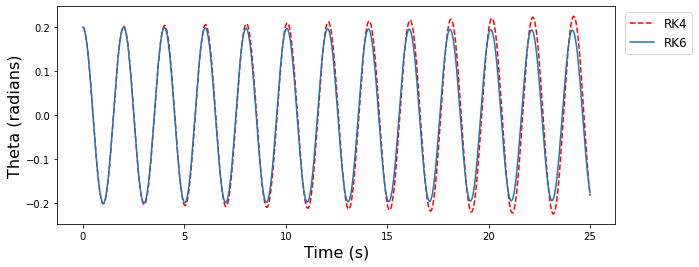

In [22]:


for i in [0.2]:
#for i in [0.2,0.4]:

    t1,theta1,v1,E1 = RK4(25,i,0,1,0.001)
    t2,theta2,v2, E2 = RK6(25,i,0,1,0.001)

    plt.figure(figsize = (10,4))

    #plt.title('RK4 vs RK6 - theta')
    plt.plot(t1,theta1, label = 'RK4',linestyle='--', color = 'red')
    plt.plot(t2,theta2, label = 'RK6')
    plt.xlabel('Time (s)',fontdict={'size': 16})
    plt.ylabel('Theta (radians)',fontdict={'size': 16})
    plt.legend(bbox_to_anchor=(1.007, 1), fontsize=12)
    plt.savefig('rk4_rk6_small.png', dpi=300)
    plt.show()

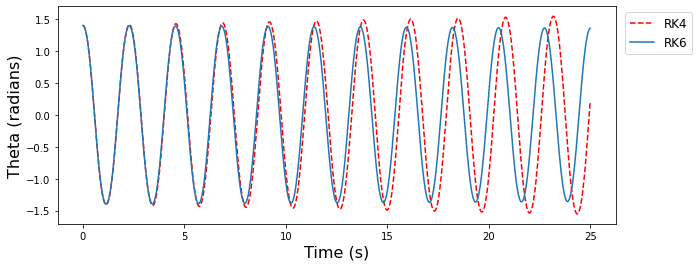

In [23]:


for i in [1.4]:
#for i in [0.2,0.4]:

    t1,theta1,v1,E1 = RK4(25,i,0,1,0.001)
    t2,theta2,v2,E2 = RK6(25,i,0,1,0.001)

    plt.figure(figsize = (10,4))

    #plt.title('RK4 vs RK6 - theta')
    plt.plot(t1,theta1, label = 'RK4',linestyle='--', color = 'red')
    plt.plot(t2,theta2, label = 'RK6')
    plt.xlabel('Time (s)',fontdict={'size': 16})
    plt.ylabel('Theta (radians)',fontdict={'size': 16})
    plt.legend(bbox_to_anchor=(1.007, 1), fontsize=12)
    plt.savefig('rk4_rk6_big.png', dpi=300)
    plt.show()

In [17]:
# Constants for the pendulum
g = 9.81  # Acceleration due to gravity (m/s^2)
l = 1.0   # Length of the pendulum (m)
theta_0 = 1.05  # Initial angle in radians
v0 = 0    # Initial angular velocity (rad/s)
t1 = 25 # Total time for the simulation
h = 0.001  # Step size for RK4

for i in [1.4]:
#for i in [0.2,0.4]:
    t_rk4, theta_rk4, v_rk4 = RK4(t1, theta_0, v0, g, l, h)
    t_rk6, theta_rk6, v_rk6 = RK6(t1, theta_0, v0, g, l, h)

    plt.figure(figsize = (10,4))

    plt.title('RK4 vs RK6 - theta')
    plt.plot(t_rk4,theta_rk4, label = 'RK4',linestyle='--', color = 'red')
    plt.plot(t_rk6,theta_rk6, label = 'RK6')
    plt.xlabel('Time (s)')
    plt.ylabel('Theta (radians)')
    plt.legend(bbox_to_anchor=(1.007, 1), fontsize=10)
    plt.savefig('rk4_rk6_big.png', dpi=300)
    plt.show()

TypeError: RK4() takes 5 positional arguments but 6 were given

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
g = 9.81  # acceleration due to gravity, in m/s^2
L = 1.0   # length of the pendulum, in meters
theta0 = np.radians(10)  # initial angle, in radians (small angle approximation)

# Time array
t = np.linspace(0, 10, 250)  # 10 seconds, 250 points

# Analytical solutions
# Position (angle as a function of time)
theta_t = theta0 * np.cos(np.sqrt(g / L) * t)

# Energy calculations
m = 1
v_t = L * np.sqrt(g / L) * theta0 * np.sin(np.sqrt(g / L) * t) 
T = 0.5 * m * (L * np.sqrt(g / L) * theta0 * np.sin(np.sqrt(g / L) * t))**2
V = m * g * L * (1 - np.cos(theta_t)) 

E = T + V 

plt.figure(figsize=(10,4))
plt.plot(t,theta_t,label='Position')
plt.plot(t,E,label='Energy')
plt.xlabel('Time (s)')
plt.ylabel('Position $θ(t)$')
plt.legend(bbox_to_anchor=(1.007, 1),fontsize=8)
plt.grid(True)
plt.savefig('analytical_energy.png',dpi=300)
plt.show()